In [1]:
import pandas as pd

df = pd.read_csv("dataset.csv") #LOADING DATASET

df.head() #PRINT 5 ROWS OF DATASET 

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type
0,81193313,Chocolate,NaN,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,"November 30, 2019",2019,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",Brought together by meaningful meals in the pa...,TV Show
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,NaN,"November 30, 2019",2019,TV-G,67 min,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,"November 30, 2019",2019,TV-14,135 min,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie
3,81082007,Atlantics,Mati Diop,"Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...","France, Senegal, Belgium","November 29, 2019",2019,TV-14,106 min,"Dramas, Independent Movies, International Movies","Arranged to marry a rich man, young Ada is cru...",Movie
4,80213643,Chip and Potato,NaN,"Abigail Oliver, Andrea Libman, Briana Buckmast...","Canada, United Kingdom",NaN,2019,TV-Y,2 Seasons,Kids' TV,"Lovable pug Chip starts kindergarten, makes ne...",TV Show


In [2]:
df.shape #PRINT SHAPE OF DATASET

(5837, 12)

In [3]:
df.columns #PRINT COLUMNS OF DATASET

Index(['show_id', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'type'],
      dtype='object')

In [4]:
df.info() #PRINT INFORMATION ABOUT DATASET 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5837 entries, 0 to 5836
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       5837 non-null   int64 
 1   title         5837 non-null   object
 2   director      3936 non-null   object
 3   cast          5281 non-null   object
 4   country       5410 non-null   object
 5   date_added    5195 non-null   object
 6   release_year  5837 non-null   int64 
 7   rating        5827 non-null   object
 8   duration      5837 non-null   object
 9   listed_in     5837 non-null   object
 10  description   5837 non-null   object
 11  type          5837 non-null   object
dtypes: int64(2), object(10)
memory usage: 547.3+ KB


In [5]:
df.describe() #DESCRIBE DATASET 

,show_id,release_year
count,5.837000e+03,5837.000000
mean,7.730079e+07,2013.688539
std,9.479777e+06,8.419088
min,2.698800e+05,1925.000000
25%,8.004520e+07,2013.000000
50%,8.016353e+07,2016.000000
75%,8.024188e+07,2018.000000
max,8.122720e+07,2020.000000


In [6]:
#CLEANING DATASET 
#Missing Values 
df.isnull().sum() #check

show_id            0
title              0
director        1901
cast             556
country          427
date_added       642
release_year       0
rating            10
duration           0
listed_in          0
description        0
type               0
dtype: int64

In [7]:
#Fill Missing Values 
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Not Available")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])
df["date_added"] = df["date_added"].fillna("Unknown")

In [8]:
df.isnull().sum() # verify 

show_id         0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
type            0
dtype: int64

In [9]:
#Check Duplicate Records 
df.duplicated().sum()

np.int64(0)

In [10]:
#Check Numeric Columns 
import numpy as np

print(df.select_dtypes(include=np.number).columns)

Index(['show_id', 'release_year'], dtype='object')


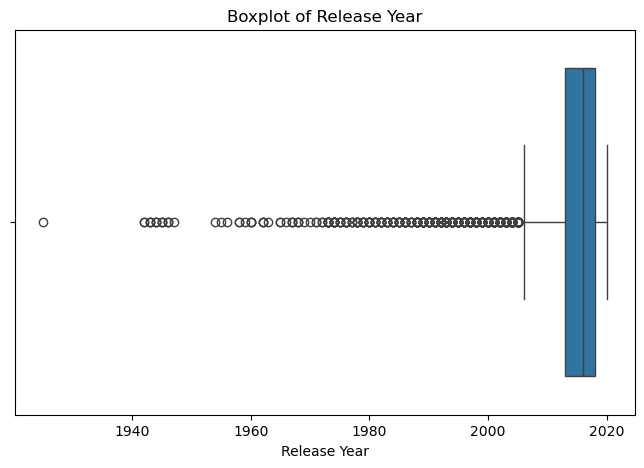

In [11]:
#Draw BoxPlot 
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=df["release_year"])
plt.title("Boxplot of Release Year")
plt.xlabel("Release Year")
plt.show()

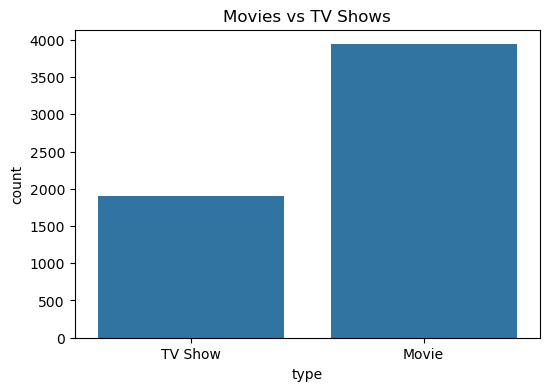

In [12]:
#VISUALIZATION 
#Movies VS T.V. Shows 
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="type")
plt.title("Movies vs TV Shows")
plt.show()

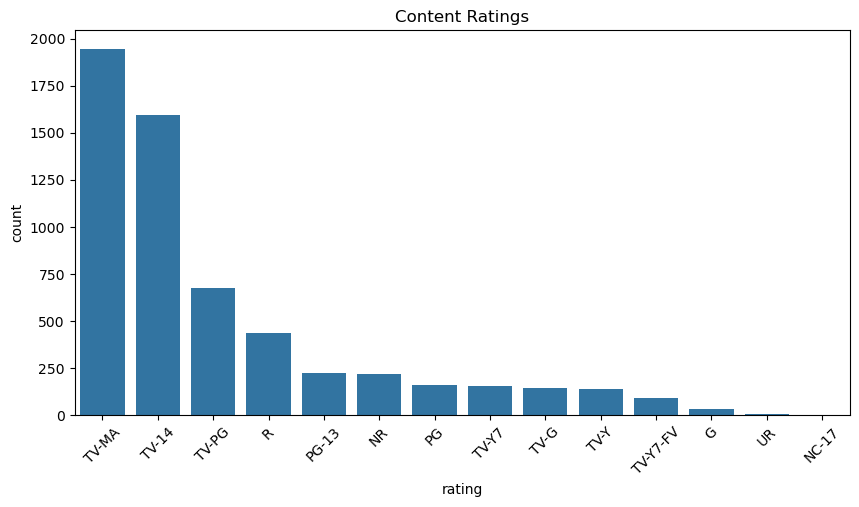

In [13]:
#Content Rating Distrubution 
plt.figure(figsize=(10,5))
sns.countplot(data=df,
              x="rating",
              order=df["rating"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Content Ratings")
plt.show()

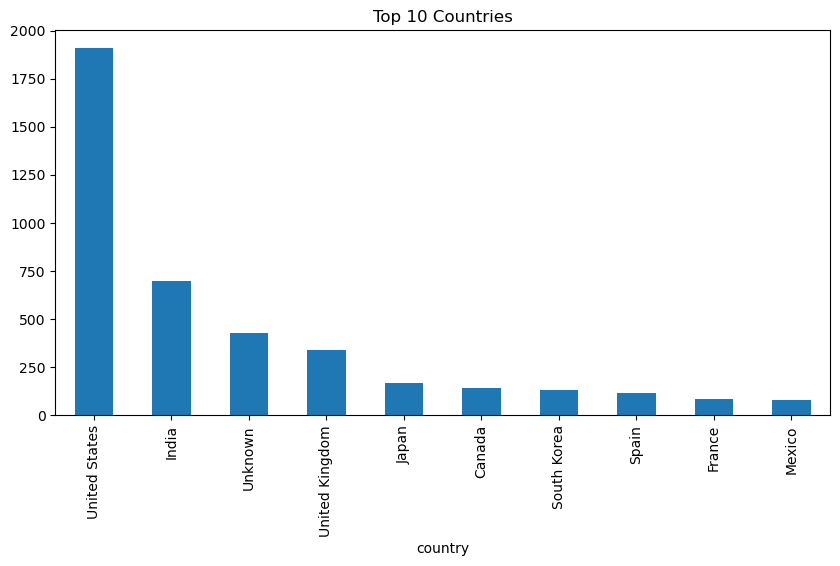

In [14]:
#Top 10 Countries 
plt.figure(figsize=(10,5))
df["country"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Countries")
plt.show()

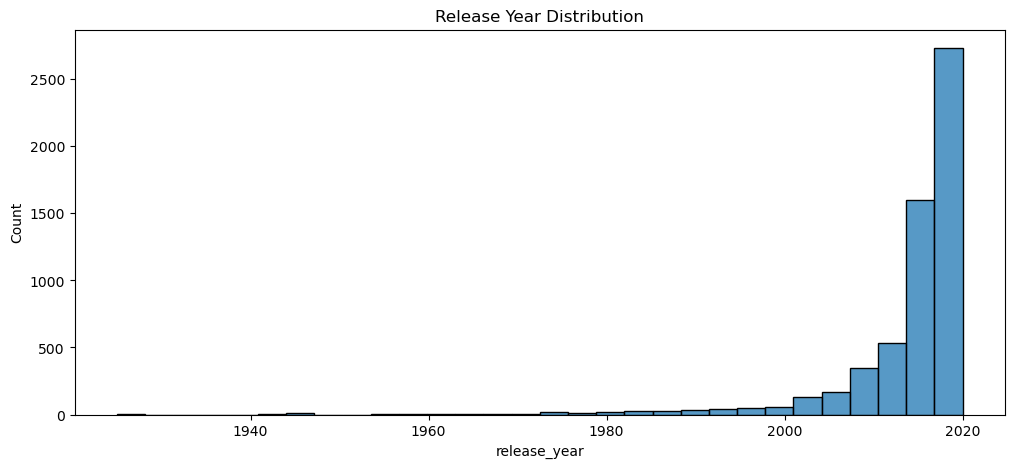

In [15]:
#Releases By Years
plt.figure(figsize=(12,5))
sns.histplot(df["release_year"], bins=30)
plt.title("Release Year Distribution")
plt.show()

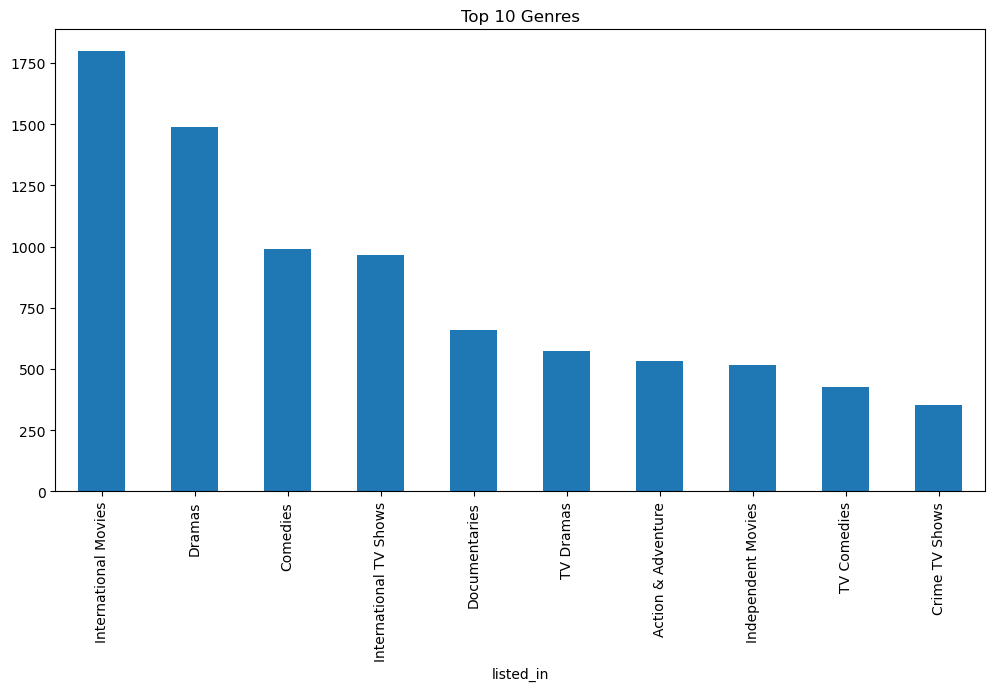

In [16]:
#Top 10 Genres
genres = df["listed_in"].str.split(", ").explode()
plt.figure(figsize=(12,6))
genres.value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Genres")
plt.show()

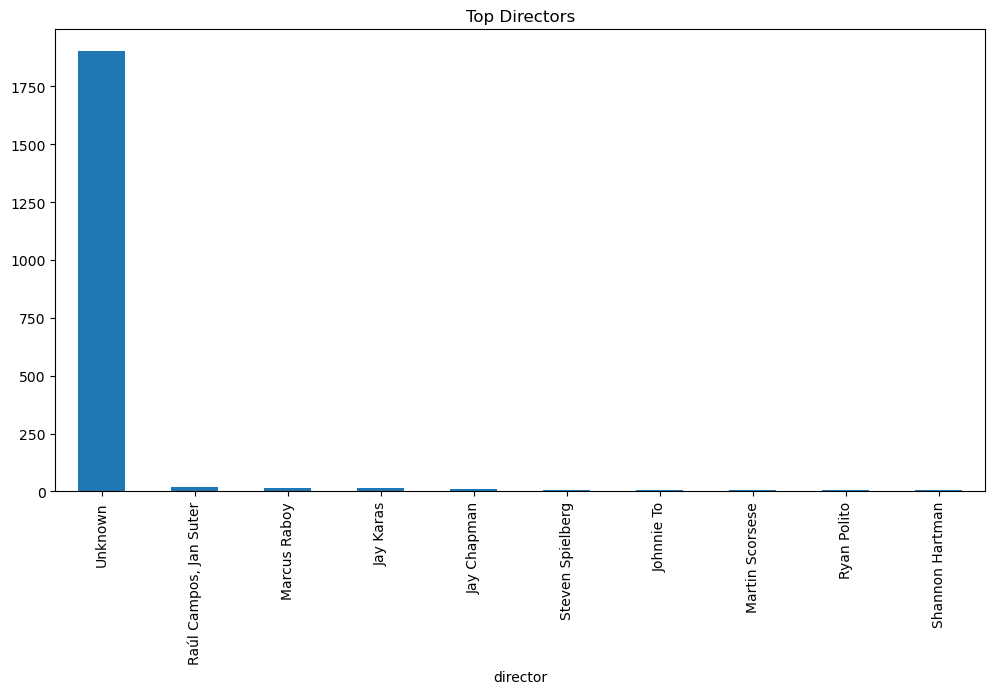

In [17]:
#Top Directors 
plt.figure(figsize=(12,6))
df["director"].value_counts().head(10).plot(kind="bar")
plt.title("Top Directors")
plt.show()

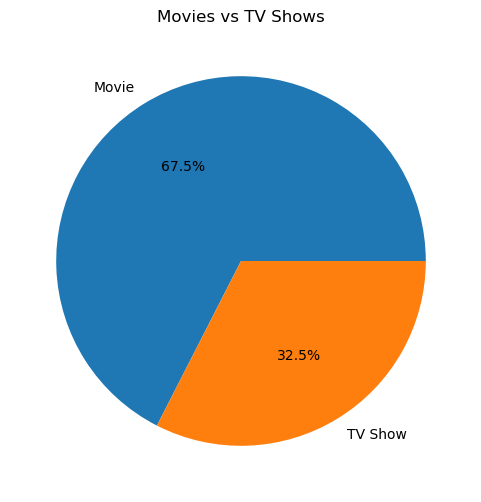

In [18]:
#PIECHART
df["type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)
plt.ylabel("")
plt.title("Movies vs TV Shows")
plt.show()

In [19]:
#SAVED CLEANED DATASET 
df.to_csv("cleaned_netflix_dataset.csv", index=False)